In [20]:
from sklearn.datasets import load_iris
import pandas as pd
iris = load_iris()
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width'
                                                , 'petal_length', 'petal_width'])
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [21]:
KM = KMeans(n_clusters=3, max_iter=300, random_state=0)
KM.fit(iris_df) #훈련/테스트 분할X
KM.labels_ #각 데이터가 속한 군집 번호

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [22]:
iris_df['target'] = iris.target #실제값
iris_df['cluster'] = KM.labels_ #모델이 정한 군집번호
iris_df.head(3)

,sepal_length,sepal_width,petal_length,petal_width,target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1


In [23]:
iris_df.groupby(['target', 'cluster'])['sepal_length'].count() 

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

# 군집의 평가: 실루엣 계수

In [30]:
from sklearn.metrics import silhouette_score, silhouette_samples
iris_df['silhouette_coeff'] = silhouette_samples(iris.data, iris_df['cluster'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,sihouette_ceff,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918,0.848918


In [31]:
silhouette_score(iris.data, iris_df['cluster'])

0.5511916046195919

In [32]:
score_sample = silhouette_samples(iris.data, iris_df['cluster'])
score_sample

array([ 0.85258191,  0.8149163 ,  0.82879659,  0.80435199,  0.84891774,
        0.7477614 ,  0.82109757,  0.8534934 ,  0.75127806,  0.82475199,
        0.80269525,  0.83540396,  0.80996716,  0.74535637,  0.70224038,
        0.64338856,  0.77526857,  0.85063272,  0.70636742,  0.81987458,
        0.78364122,  0.82546665,  0.79244412,  0.79345251,  0.77426479,
        0.79799564,  0.83296108,  0.84162136,  0.84325046,  0.81723402,
        0.8145665 ,  0.79849826,  0.76227879,  0.72184605,  0.82822866,
        0.83179477,  0.79374024,  0.84148042,  0.76779363,  0.84992603,
        0.84902387,  0.63767419,  0.78589195,  0.79963167,  0.74629437,
        0.80915172,  0.81295565,  0.81844011,  0.81783314,  0.85168255,
       -0.02672203,  0.36827154,  0.08489767,  0.59610609,  0.35669884,
        0.59416206,  0.27019063,  0.27245453,  0.32755642,  0.58167084,
        0.38107057,  0.58665651,  0.55085685,  0.47851679,  0.56757079,
        0.30479553,  0.5596951 ,  0.61137194,  0.46029717,  0.61

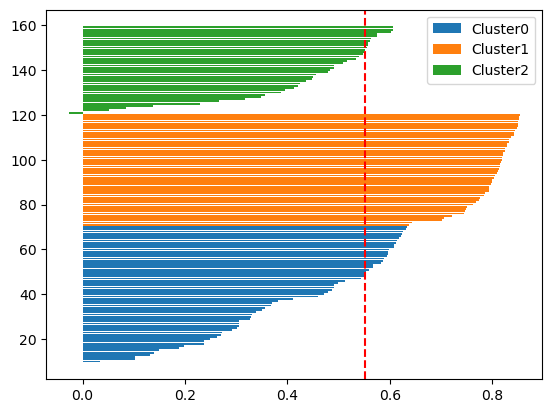

In [33]:
# 실루엣계수 시각화
import matplotlib.pyplot as plt
y_lower = 10

for i in range(3):
  cluster_i = score_sample[iris_df['cluster'] == i]
  cluster_i.sort()
  y_upper = y_lower + len(cluster_i)
  plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
  y_lower = y_upper
  
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--')
plt.legend()
plt.show()

In [ ]:
# k의 값을 조정 데이터 스케일링

# k 값의 선택을 위한 스크리 차트

In [34]:
scree_df = iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
sse_values = []

k_values = range(1,11)
for k in k_values:
  kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, random_state=0)
  kmeans.fit(scree_df)
  sse_values.append(kmeans.inertia_)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarn

In [24]:
KM = KMeans(n_clusters=3, init='k-means++', random_state=0)
KM.fit(iris_df) #훈련/테스트 분할X
KM.labels_ #각 데이터가 속한 군집 번호  

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0], dtype=int32)

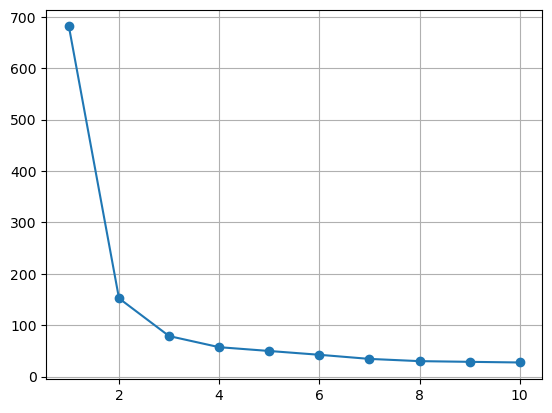

In [35]:
plt.plot(k_values, sse_values, marker='o')
plt.grid()
plt.show()

# iris_df의 차원 축소

In [37]:
from sklearn.decomposition import PCA

# PCA 객체 생성 (주성분 2개로 축소)
pca = PCA(n_components=2)

# 데이터 변환
X_pca = pca.fit_transform(iris.data)

# 설명된 분산 비율 확인
print(pca.explained_variance_ratio_)

[0.92461872 0.05306648]


In [ ]:
X_pca

In [38]:
iris_df['pca_x'] = X_pca[:, 0]
iris_df['pca_y'] = X_pca[:, 1]
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,sihouette_ceff,silhouette_coeff,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,0.852582,0.852582,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,0.814916,0.814916,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,0.828797,0.828797,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,0.804352,0.804352,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,0.848918,0.848918,-2.728717,0.326755


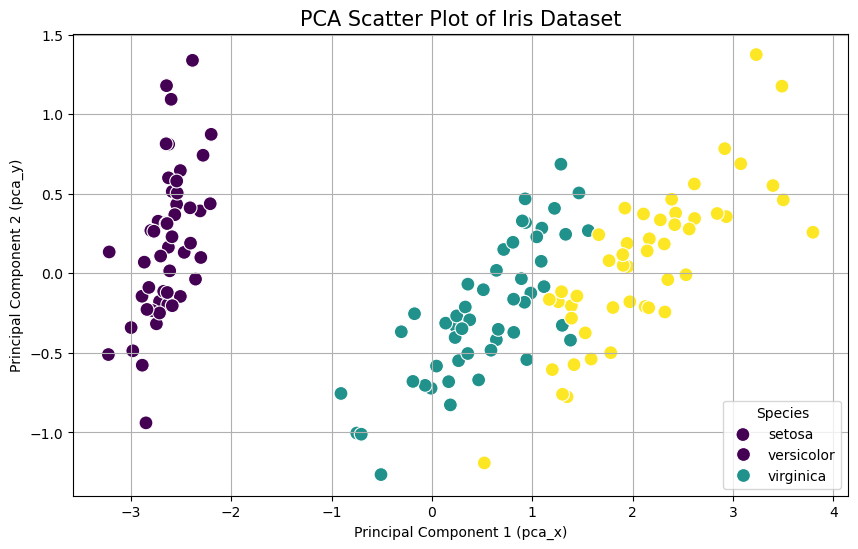

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.decomposition import PCA

# 1. 데이터 로드 및 PCA 변환 (사용자 환경에 맞춰 재구성)
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target

# PCA 수행 (2차원으로 축소)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(iris.data)

# 질문에 제시된 코드: PCA 결과를 데이터프레임에 추가
iris_df['pca_x'] = X_pca[:, 0]
iris_df['pca_y'] = X_pca[:, 1]

# 2. 산점도 시각화
plt.figure(figsize=(10, 6))

# seaborn을 사용하면 라벨링(target별 색상 구분)과 범례(legend)를 쉽게 처리할 수 있습니다.
sns.scatterplot(
    x='pca_x', 
    y='pca_y', 
    hue='target',       # 'target' 컬럼에 따라 색상을 다르게 표시 (라벨링)
    palette='viridis',   # 색상 테마 설정
    data=iris_df,
    s=100               # 점의 크기
)

# 그래프 제목 및 축 이름 설정
plt.title('PCA Scatter Plot of Iris Dataset', fontsize=15)
plt.xlabel('Principal Component 1 (pca_x)')
plt.ylabel('Principal Component 2 (pca_y)')

# 범례(Legend) 설정: 0, 1, 2 대신 실제 꽃 이름을 표시하고 싶다면 아래와 같이 설정 가능합니다.
plt.legend(title='Species', labels=iris.target_names)

plt.grid(True)
plt.show()

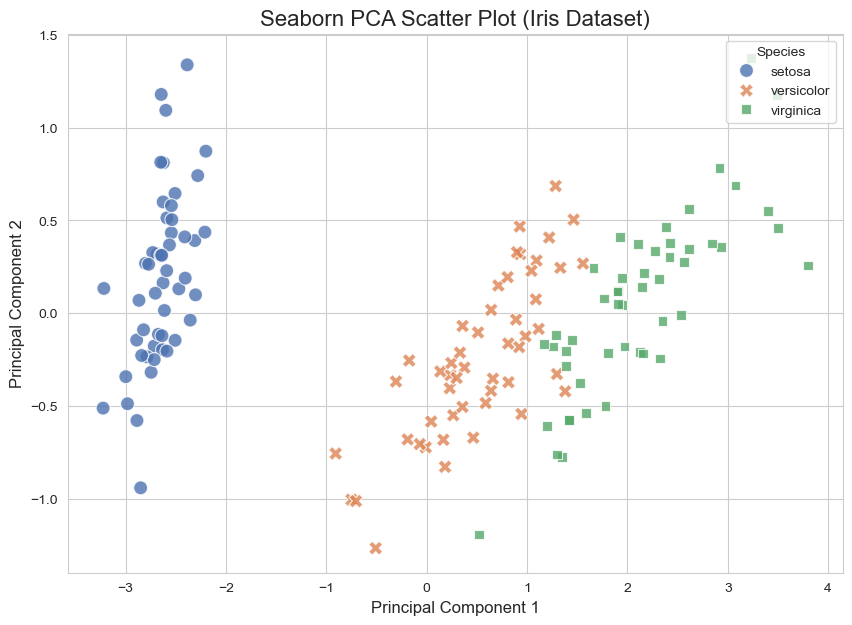

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 스타일 설정 (선택 사항: whitegrid, darkgrid 등)
sns.set_style("whitegrid")

# 2. 산점도 그리기
plt.figure(figsize=(10, 7))

# sns.scatterplot의 핵심 파라미터:
# x, y: 데이터프레임의 컬럼명
# hue: 데이터의 종류(라벨)에 따라 색상을 다르게 지정
# style: 데이터의 종류에 따라 점의 모양(shape)을 다르게 지정
scatter = sns.scatterplot(
    data=iris_df, 
    x='pca_x', 
    y='pca_y', 
    hue='target',       # 품종별 색상 구분
    style='target',     # 품종별 모양 구분 (추가적인 라벨링 효과)
    palette='deep',     # 색상 테마 (bright, pastel, muted 등)
    s=100,              # 점의 크기
    alpha=0.8           # 점의 투명도
)

# 3. 그래프 디테일 설정
plt.title('Seaborn PCA Scatter Plot (Iris Dataset)', fontsize=16)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)

# 범례(Legend)의 0, 1, 2 숫자를 실제 이름으로 변경하고 싶을 때
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, iris.target_names, title='Species', loc='upper right')

plt.show()

# Gemini iris_df 피처를 스케일링 [StandardScaling]

In [48]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. 데이터 로드
iris = load_iris()

# [중요] 컬럼명을 ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']로 변경하여 생성
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df['target'] = iris.target

# 2. 스탠다드 스케일링 (첫 번째 단계)
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
x = iris_df[features]

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(x)

# 3. PCA 주성분 분석 (두 번째 단계)
pca = PCA(n_components=2)
pca_fitted = pca.fit_transform(iris_scaled)

# PCA 결과를 데이터프레임에 추가
iris_df['pca_x'] = pca_fitted[:, 0]
iris_df['pca_y'] = pca_fitted[:, 1]

print("--- PCA 변환 및 데이터프레임 병합 완료 ---")
print(iris_df[['pca_x', 'pca_y', 'target']].head())
print(f"\n설명 가능한 분산 비율: {pca.explained_variance_ratio_}")

--- PCA 변환 및 데이터프레임 병합 완료 ---
      pca_x     pca_y  target
0 -2.264703  0.480027       0
1 -2.080961 -0.674134       0
2 -2.364229 -0.341908       0
3 -2.299384 -0.597395       0
4 -2.389842  0.646835       0

설명 가능한 분산 비율: [0.72962445 0.22850762]


# Gemini 주성분 분석 2 [PCA]

In [49]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 0. 데이터 준비 (KeyError 방지를 위해 컬럼명 지정)
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris_df['target'] = iris.target

# --- 첫 번째 코드: 스탠다드 스케일링 ---
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
x = iris_df[features]

# StandardScaler를 이용해 평균 0, 분산 1로 변환
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(x) # 여기서 iris_scaled가 생성됩니다!

print("--- 1. 스탠다드 스케일링 완료 ---")


# --- 두 번째 코드: PCA 분석 ---
# 1. PCA 객체 생성 (주성분 개수 2개 설정)
pca = PCA(n_components=2)

# 2. 위에서 생성한 'iris_scaled'를 바탕으로 PCA 수행
pca_fitted = pca.fit_transform(iris_scaled)

# 3. PCA 결과를 iris_df에 새로운 컬럼으로 추가
iris_df['pca_x'] = pca_fitted[:, 0]
iris_df['pca_y'] = pca_fitted[:, 1]

print("\n--- 2. PCA 변환 완료 ---")
print(f"설명 가능한 분산 비율 (Explained Variance Ratio): {pca.explained_variance_ratio_}")
print(iris_df[['pca_x', 'pca_y', 'target']].head())

--- 1. 스탠다드 스케일링 완료 ---

--- 2. PCA 변환 완료 ---
설명 가능한 분산 비율 (Explained Variance Ratio): [0.72962445 0.22850762]
      pca_x     pca_y  target
0 -2.264703  0.480027       0
1 -2.080961 -0.674134       0
2 -2.364229 -0.341908       0
3 -2.299384 -0.597395       0
4 -2.389842  0.646835       0


# iris_df 피처를 스케일링 [StandardScaling]

In [50]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [51]:
# iris_df 피처를 스케일링
# iris_df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)

pca_scaled = PCA(n_components=2)
X_pca_scaled = pca_scaled.fit_transform(X_scaled)

print("스케일링 후 설명분산비율:", pca_scaled.explained_variance_ratio_)
print("스케일링 후 누적설명분산:", sum(pca_scaled.explained_variance_ratio_))

스케일링 후 설명분산비율: [0.72962445 0.22850762]
스케일링 후 누적설명분산: 0.9581320720000164


# 2개의 주성분 설명력 확인
주성분 분석 2

# 2개의 주성분 설명력 확인

scale 전 : [0.92461872 0.05306648]
scale 후 : [0.72962445 0.22850762]

In [53]:
features = ['sepal_length', 'sepal_width', 
            'petal_length', 'petal_width']

In [54]:
loadings_scaled = pd.DataFrame(
    pca_scaled.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)

print("\n=== 스케일링 후 설명분산비율 ===")
print(pca_scaled.explained_variance_ratio_)

print("\n=== 스케일링 후 로딩값 ===")
print(loadings_scaled)


=== 스케일링 후 설명분산비율 ===
[0.72962445 0.22850762]

=== 스케일링 후 로딩값 ===
                   PC1       PC2
sepal_length  0.521066  0.377418
sepal_width  -0.269347  0.923296
petal_length  0.580413  0.024492
petal_width   0.564857  0.066942
